In [1]:
# import os
import torch
# import torch.nn as nn
# import torch.nn.functional as F

import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


from scipy.io import loadmat
# import os
# import scipy.io as sio
# import numpy.linalg as la
# from tqdm import tqdm

from koopman_pseudospec_qr import KoopPseudoSpecQR
# from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
print (torch.__version__, torch.cuda.is_available())
# device= 'cuda'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device= 'cpu'
torch.set_default_dtype(torch.float64)

# torch.cuda.get_device_name()

2.7.1+cu126 True


In [3]:
# Load the specified MAT-file using scipy.io.loadmat()
file_path = 'data/pendulum/data_pendulum_90.mat'

# file_path = 'data_pendulum_90.mat'
data_pendulum = loadmat(file_path)

In [4]:
# Assuming the loaded MAT-file is named data_pendulum_90
X = data_pendulum['DATA_X']
Y = data_pendulum['DATA_Y']

print(X.shape)

(90000, 2)


In [5]:
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

In [6]:
checkpoint_file= 'koopman_example_ckpt002.torch'

In [7]:
from solver_resdmd_torch import KoopmanNNTorch, KoopmanSolverTorch

dic_size = 300

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[300,300,300], n_psi_train=dic_size-3).to(device)

solver = KoopmanSolverTorch(dic=basis_function,
                         target_dim=np.shape(data_x_train)[-1],
                         reg=0.1, checkpoint_file= checkpoint_file)

# torch.cuda.get_device_name()

solver.build(data_train=data_train,
             data_valid=data_valid,
             epochs=16,
             batch_size=256,
             lr=1e-5,
             log_interval=10,
             lr_decay_factor=.8)

Outer Epoch 1/16
Epoch: 1 	Training Loss: 0.097315 val loss: 0.063204
saving, val loss enhanced: 0.06320428269553764 10000
Epoch: 2 	Training Loss: 0.054988 val loss: 0.042146
saving, val loss enhanced: 0.042146090477524 0.06320428269553764
Epoch 1 time: 12.05 seconds
Outer Epoch 2/16
Epoch: 1 	Training Loss: 0.108223 val loss: 0.058608
Epoch: 2 	Training Loss: 0.050689 val loss: 0.040232
saving, val loss enhanced: 0.0402324760322765 0.042146090477524
Epoch 2 time: 10.44 seconds
Outer Epoch 3/16
Epoch: 1 	Training Loss: 0.142733 val loss: 0.083440
Epoch: 2 	Training Loss: 0.071544 val loss: 0.054010
Epoch 3 time: 9.24 seconds
Outer Epoch 4/16
Epoch: 1 	Training Loss: 0.149321 val loss: 0.080289
Epoch: 2 	Training Loss: 0.068784 val loss: 0.051804
Epoch 4 time: 9.36 seconds
Outer Epoch 5/16
Epoch: 1 	Training Loss: 0.143458 val loss: 0.088727
Epoch: 2 	Training Loss: 0.078908 val loss: 0.061345
Epoch 5 time: 9.21 seconds
Outer Epoch 6/16
Epoch: 1 	Training Loss: 0.119605 val loss: 0.075

In [8]:
## Steps:
# Changed the formulation of the eigenvectors and eigenvalues to make sure that they're fixed in the inner loops.
# Made sure that computational graph was not broken for psi in forward step in inner loop. 


In [9]:
solver.koopman_model.layer_K.weight

Parameter containing:
tensor([[ 9.5276e-01,  7.7976e-02,  6.9326e-04,  ..., -5.2745e-03,
         -1.4639e-03, -7.0846e-03],
        [ 5.9565e-04,  5.0970e-01,  8.0710e-04,  ..., -4.2925e-03,
         -1.1144e-03, -8.1405e-04],
        [-1.7175e-05, -7.2482e-02,  9.9995e-01,  ..., -1.7564e-04,
         -3.4202e-04,  2.6941e-04],
        ...,
        [-5.5644e-03,  1.1416e+00,  1.4568e-04,  ...,  1.3504e-01,
         -3.3750e-03,  4.8605e-03],
        [-2.0078e-03,  1.9332e+00,  4.3338e-04,  ...,  6.1242e-03,
          1.9046e-01, -6.4007e-03],
        [-6.4510e-03, -2.0119e+00,  3.5358e-04,  ..., -1.5300e-02,
         -1.2785e-02,  1.0760e-01]], device='cuda:0')

In [10]:
solver.koopman_model.layer_lambda_diag.weight.data.diag()

tensor([ 1.0000e+00+1.2627e-07j,  1.0000e+00-1.2627e-07j,
         9.9998e-01+0.0000e+00j,  9.9992e-01+0.0000e+00j,
         9.9985e-01+8.2161e-04j,  9.9985e-01-8.2161e-04j,
         9.9972e-01+0.0000e+00j,  9.9941e-01+7.0982e-03j,
         9.9941e-01-7.0982e-03j,  9.9923e-01+2.6278e-03j,
         9.9923e-01-2.6278e-03j,  9.9913e-01+0.0000e+00j,
         9.9830e-01-4.7026e-03j,  9.9830e-01+4.7026e-03j,
         9.9812e-01-1.7829e-03j,  9.9812e-01+1.7829e-03j,
         9.9483e-01+0.0000e+00j,  9.9323e-01-2.5485e-03j,
         9.9323e-01+2.5485e-03j,  9.9220e-01-1.1868e-02j,
         9.9220e-01+1.1868e-02j,  9.8841e-01-6.4189e-03j,
         9.8841e-01+6.4189e-03j,  9.8434e-01+0.0000e+00j,
         9.7998e-01-3.0099e-03j,  9.7998e-01+3.0099e-03j,
         9.7163e-01+0.0000e+00j,  9.6797e-01+0.0000e+00j,
         9.5350e-01-5.1437e-03j,  9.5350e-01+5.1437e-03j,
         9.4052e-01+0.0000e+00j,  9.3002e-01+1.6008e-03j,
         9.3002e-01-1.6008e-03j,  9.0621e-01+0.0000e+00j,
         8.712

In [11]:
# Results from solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver.get_Psi_X().detach().cpu().numpy()
Psi_Y = solver.get_Psi_Y().detach().cpu().numpy()
Koopman_matrix_K = solver.K.detach().cpu().numpy()
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    'K': Koopman_matrix_K,
    'Psi_X': Psi_X,
    'Psi_Y': Psi_Y
}

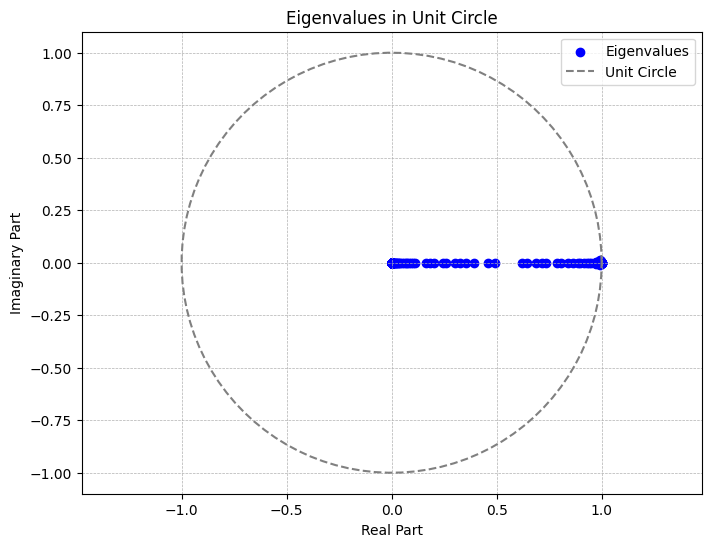

In [12]:
# Assuming evalues is a numpy array of complex numbers
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [9]:
# # Define the folder path
# folder_path = 'data/pendulum_data'
# # Create the folder if it doesn't exist
# os.makedirs(folder_path, exist_ok=True)

# # Save the outputs to a .mat file named according to the number of basis functions, inside the specified folder
# file_path = os.path.join(folder_path, f'pendulum_90_resdmd_{N_dict}basis.mat')
# sio.savemat(file_path, outputs)
# print(f'Saved outputs for n_psi_train={N_dict} to {file_path}')

In [3]:
file_path = 'pendulum_90_resdmd_300basis.mat'

data_pendulum = loadmat(file_path)

Psi_X = data_pendulum['Psi_X']
Psi_Y = data_pendulum['Psi_Y']
dic_size = data_pendulum['N_dict'][0]
print(dic_size)

[300]


In [15]:
## Compute residual
m= Psi_X.shape[0]
print (m)
W = np.ones((m, 1), dtype= np.double)
G= np.dot(Psi_X.T , Psi_X)
print (G.shape)
print ('cond(G) is:',la.cond(G))
x_pts= arange (-1.5, 1.5+0.05, 0.05)
y_pts=x_pts
print (x_pts.shape)
#z_pts=kron(x_pts,ones((len(y_pts),1))+1j*kron(ones((1,len(x_pts))),y_pts))  #  z_pts=z_pts(:);
x_pts_mesh,y_pts_mesh= meshgrid (x_pts, y_pts)
z_pts= x_pts_mesh + 1j*y_pts_mesh
z_pts= z_pts.ravel()
RES= KoopPseudoSpecQR(Psi_X,Psi_Y,W,z_pts)
RES= RES.reshape (x_pts_mesh.shape)

lower_bound = 1e-16#; % Example lower bound
#Find indices where the real part of RES is zero
zero_real_indices =nonzero (np.real(RES)==0)
#% Replace only the real part of RES elements that are zero with the lower bound
RES[zero_real_indices] = lower_bound + imag(RES[zero_real_indices]) * 1j

168000
(300, 300)
cond(G) is: 2.375728787345549e+20
(61,)


100%|██████████| 3721/3721 [08:13<00:00,  7.54it/s]


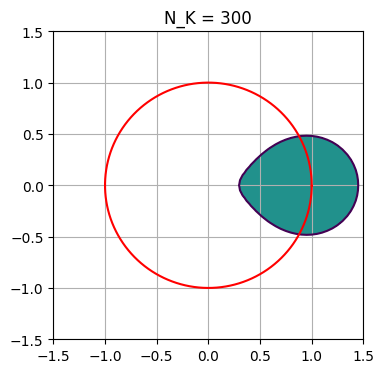

In [16]:
## Plot the pseudospectrum
plt.figure(figsize=(4, 4))  # Set the plot size (width, height) in inches
v= array ([0.25, 1e-64])
plt.contourf(x_pts_mesh,y_pts_mesh,log10(1/real(RES)),levels= log10(1/v))
plt.contour(x_pts_mesh,y_pts_mesh,log10(1/real(RES)),levels= log10(1/v))
circle_phi= arange (0, 2*np.pi ,2*np.pi/1000 )
plt.plot (np.cos(circle_phi), np.sin(circle_phi), color= 'red')
plt.grid()
plt.title(f'N_K = {dic_size}')
plt.show()

In [ ]:
Psi

In [14]:
# Check 1: are your snapshot pairs correct?
print("Max |y_i - x_i|:", np.max(np.abs(Y - X)))  # should be nonzero
print("Correlation of PsiX and PsiY:", np.corrcoef(Psi_X.flat, Psi_Y.flat)[0,1])

# Check 2: is K real?
print("Max imaginary part of K:", np.max(np.abs(np.imag(Koopman_matrix_K))))

# Check 3: is G well-conditioned?
# print("Condition number of G:", np.linalg.cond(G))

# Check 4: eigenvalue magnitudes
eigs = np.linalg.eigvals(Koopman_matrix_K)
print("Eigenvalue magnitudes:", np.abs(eigs))

Max |y_i - x_i|: 6.282366790205614
Correlation of PsiX and PsiY: 0.9998659143753126
Max imaginary part of K: 0.0
Eigenvalue magnitudes: [8.44261537e-01 8.76195880e-01 8.95626219e-01 9.06884856e-01
 9.31110983e-01 9.49350636e-01 9.61423439e-01 9.61423439e-01
 9.62065696e-01 9.68601580e-01 9.94434661e-01 9.94434661e-01
 9.89466491e-01 9.89466491e-01 9.84520389e-01 9.84520389e-01
 9.84864725e-01 9.87816158e-01 9.99436584e-01 9.99436584e-01
 9.92212107e-01 9.92212107e-01 9.98759885e-01 9.98759885e-01
 9.99418387e-01 9.99418387e-01 9.97362677e-01 9.97362677e-01
 9.99891399e-01 9.99891399e-01 9.98556549e-01 9.98966720e-01
 9.99896361e-01 9.99992973e-01 1.00000007e+00 9.99999873e-01
 7.99045660e-01 8.18760552e-01 6.92804577e-01 7.40156919e-01
 5.62913456e-01 5.77262438e-01 6.04744710e-01 6.74564583e-01
 5.12587102e-01 4.41611910e-01 4.11221529e-01 3.49016488e-01
 3.38381395e-01 2.83872465e-01 2.46252052e-01 2.09632293e-01
 1.73458116e-01 1.60560059e-01 1.42659384e-01 1.06074184e-01
 8.5977296

In [11]:
# ## Save the data to local folder

# import scipy.io as sio

# # Adjustments for ensuring double precision and retaining complex nature
# outputs = {
#     'efuns': efuns.astype(np.complex128),
#     'evalues': evalues.astype(np.complex128),
#     'kpm_modes': kpm_modes.astype(np.complex128),
#     'N_dict': np.array([N_dict], dtype=np.float64),  # Keeping N_dict as a double precision float
#     'K': Koopman_matrix_K.astype(np.float64),
#     'Psi_X': Psi_X.astype(np.float64),
#     'Psi_Y': Psi_Y.astype(np.float64),
#     # Uncomment and adjust if these are used in your code
#     # 'Psi_X2': Psi_X2.astype(np.complex128),
#     # 'Psi_Y2': Psi_Y2.astype(np.complex128)
# }

# # Proceed with saving as before


# folder_path = 'data/pendulum_data'  # Adjust the path as needed if you want a different location
# os.makedirs(folder_path, exist_ok=True)
# # Save the outputs to a .mat file named according to the number of basis functions, inside the "data" folder
# file_path = os.path.join(folder_path, f'pendulum_90_edmd_{N_dict}basis.mat')
# sio.savemat(file_path, outputs)
# print(f'Saved outputs for n_psi_train={N_dict} to {file_path}')





In [12]:
# ### Calculate for multiple numbers of basis ###
# import os
# import scipy.io as sio

# from solver_resdmd import KoopmanNN, KoopmanSolver

# dic_size = [25, 50, 100, 150, 200, 250, 300] # basis number would be 25, 50, 100, 150, 200, 250, 300

# for n_psi in dic_size:
#     # Initialize the basis function with the current value of dic_size
#     basis_function = KoopmanNN(layer_sizes=[400,400,400], n_psi_train=n_psi-3)

#     # Initialize the solver with the basis function and other parameters
#     solver = KoopmanSolver(dic=basis_function,
#                              target_dim=np.shape(data_x_train)[-1],
#                              reg=0.1)
#     # Build the solver with the specified training and validation data
#     solver.build(data_train=data_train,
#                  data_valid=data_valid,
#                  epochs=3,
#                  batch_size=50000,
#                  lr=1e-4,
#                  log_interval=10,
#                  lr_decay_factor=.8)

#     # Assuming the user has these functions or similar ones defined in their environment
#     evalues = solver.eigenvalues.T
#     efuns = solver.eigenfunctions(X)
#     kpm_modes = solver.compute_mode().T
#     N_dict = np.shape(evalues)[0]
#     Koopman_matrix_K = solver.K.numpy()
#     Psi_X = solver.get_Psi_X().numpy()
#     Psi_Y = solver.get_Psi_Y().numpy()
#     # Psi_X2, Psi_Y2 = solver.get_basis(data_x_train, data_y_train) # basis are orthonormal
#     # Psi_X2 = Psi_X2.numpy()
#     # Psi_Y2 = Psi_Y2.numpy()
#     # jacobian, hessian = solver.get_derivatives(data_x_valid) # Currently the storage is not enough to calculate for larger amount of data
#     # np_config.enable_numpy_behavior()
#     outputs = {
#         'efuns': efuns,
#         'evalues': evalues,
#         'kpm_modes': kpm_modes,
#         'N_dict': N_dict,
#         'K': Koopman_matrix_K,
#         'Psi_X': Psi_X,
#         'Psi_Y': Psi_Y,
#         # 'Psi_X2': Psi_X2,
#         # 'Psi_Y2': Psi_Y2,
#         # "Jacobian": jacobian,  # Uncomment if needed
#         # "Hessian": hessian,    # Uncomment if needed
#     }

#     folder_path = 'data/pendulum_data'  # Adjust the path as needed if you want a different location
#     os.makedirs(folder_path, exist_ok=True)
#     # Save the outputs to a .mat file named according to the number of basis functions, inside the "data" folder
#     file_path = os.path.join(folder_path, f'pendulum_90_resdmd_{N_dict}basis.mat')
#     sio.savemat(file_path, outputs)
#     print(f'Saved outputs for n_psi_train={n_psi} to {file_path}')

In [13]:
# ## Plot the pseudospectrum from multiple trained data files
# import numpy as np
# from numpy import linalg as la
# from numpy import *
# from koopman_pseudospec_qr import KoopPseudoSpecQR
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap, BoundaryNorm
# import scipy.io as sio

# # Define arrays for solver numbers and nd values
# n_basis = [25, 50, 100, 150, 200, 250, 300, 350]

# # Loop over each solver number
# for nd in n_basis:
#     # Construct the file name        
#     filename = f'pendulum_240_resdmd_{nd}basis.mat'

#     # Load the file
#     data = sio.loadmat(filename)

#     # Assuming PX is already defined and is an m x n matrix
#     Psi_X = data['Psi_X']
#     Psi_Y = data['Psi_Y']
#     m= Psi_X.shape[0]
#     print (m)
#     W = np.ones((m, 1), dtype= np.double)
#     G= np.dot(Psi_X.T , Psi_X)
#     print (G.shape)
#     print ('cond(G) is:',la.cond(G))
#     x_pts= arange (-1.5, 1.5+0.05, 0.05)
#     y_pts=x_pts
#     print (x_pts.shape)
#     #z_pts=kron(x_pts,ones((len(y_pts),1))+1j*kron(ones((1,len(x_pts))),y_pts))  #  z_pts=z_pts(:);
#     x_pts_mesh,y_pts_mesh= meshgrid (x_pts, y_pts)
#     z_pts= x_pts_mesh + 1j*y_pts_mesh
#     z_pts= z_pts.ravel()
#     RES= KoopPseudoSpecQR(Psi_X,Psi_Y,W,z_pts)
#     RES= RES.reshape (x_pts_mesh.shape)
    
#     lower_bound = 1e-16#; % Example lower bound
#     #Find indices where the real part of RES is zero
#     zero_real_indices =nonzero (np.real(RES)==0)
#     #% Replace only the real part of RES elements that are zero with the lower bound
#     RES[zero_real_indices] = lower_bound + imag(RES[zero_real_indices]) * 1j

#     # Plot 1st type of image
#     v= array ([0.25, 1e-64])
#     plt.figure(figsize=(4, 4))  # Set the plot size (width, height) in inches
#     plt.contourf(x_pts_mesh,y_pts_mesh,log10(1/real(RES)),levels= log10(1/v))
#     plt.contour(x_pts_mesh,y_pts_mesh,log10(1/real(RES)),levels= log10(1/v))
#     circle_phi= arange (0, 2*np.pi ,2*np.pi/1000 )
#     plt.plot (np.cos(circle_phi), np.sin(circle_phi), color= 'red')
#     plt.title(f'N_K = {nd}')
#     plt.grid()
#     # Save the figure as a PNG file
#     png_file_name = f'pendulum_240_resdmd_{nd}basis_1.png'
#     plt.savefig(png_file_name)
#     plt.show()




#     # Set the threshold
#     threshold = 0.25
#     # Create a custom colormap
#     colors = ['lightgreen', 'white']
#     cmap = ListedColormap(colors)
#     # Define the boundaries for the colormap
#     boundaries = [np.min(np.real(RES)), threshold, np.max(np.real(RES))]
#     norm = BoundaryNorm(boundaries, cmap.N, clip=True)
#     # Plot 2nd type of image
#     plt.figure(figsize=(4, 4))  # Set the plot size (width, height) in inches
#     plt.pcolormesh(x_pts_mesh, y_pts_mesh, np.real(RES), shading='gouraud', cmap=cmap, norm=norm)
#     plt.title(f'N_K = {nd}')
#     # plt.colorbar()  # Add colorbar
#     # Save the figure as a PNG file
#     png_file_name = f'pendulum_240_resdmd_{nd}basis_2.png'
#     plt.savefig(png_file_name)
#     plt.show()

